# FCM Code

### Import Modules

In [ ]:
import mlhp
import datetime
import os
import numpy as np
import matplotlib.pyplot as plt
from vtk import vtkPolyData, vtkPoints, vtkCellArray, vtkLine, vtkXMLPolyDataWriter, vtkVertex
from math import sqrt

### Track start time & define workspaces

In [ ]:
starttime=datetime.datetime.now()
outputDir="/Applications/Datein_Timon/Bildung/Uni_Rostock/Master_MaschBau/3_Semester/Studienarbeit/Code/FCM-StA/outputsWuerfel1" 

### 1. Setting up mesh and basis

In [ ]:
D = 3

# Setup triangulation domain
triangulation = mlhp.readStl("/Applications/Datein_Timon/Bildung/Uni_Rostock/Master_MaschBau/3_Semester/Studienarbeit/Code/FCM-StA/FCM/Wuerfel1.stl")
kdtree = mlhp.buildKdTree(triangulation)
domain = mlhp.implicitTriangulation(triangulation, kdtree)

# Setup discretization
youngsModulus = 1e11 # youngs modulus in N/m2
poissonsRatio = 0.3

polynomialDegree = 2 
nelements = [30]*D # original value was 50
alphaFCM = 1e-5
penalty = 1e5 * youngsModulus

origin, max = triangulation.boundingBox()
lengths = [m - o for o, m in zip(origin, max)] 
origin = [o - 1e-10 for o in origin]
max = [m + 1e-10 for m in max]
#debugging
print("STL Bounding Box:")
print("  Origin :", origin)
print("  Max    :", max)
print("  Length :", lengths)
print("  Fix unten bei z <", origin[2] + lengths[2]*0.01)
print("  Drück oben bei z >", origin[2] + lengths[2]*0.99)

#grid = mlhp.makeRefinedGrid(nelements, lengths, origin)# wenn DOF von 1640442 auf 3090903 gehen alles klar
grid = mlhp.makeGrid(nelements, lengths, origin) #grobes gitter
grid = mlhp.makeRefinedGrid(mlhp.makeFilteredGrid(grid, domain=domain, nseedpoints=polynomialDegree + 2))#filterung mit stl-domain

basis = mlhp.makeHpTensorSpace(grid, polynomialDegree, nfields=D)
print(basis)

#### 2. Probe line generation and export to ParaView

In [ ]:
# Mitte von Y und Z
mid_y = origin[1] + 0.5 * lengths[1]
mid_z = origin[2] + 0.5 * lengths[2]

# 50 Punkte entlang X zur Visualisierung
x_vals = np.linspace(origin[0], max[0], 50)
line_pts = [(x, mid_y, mid_z) for x in x_vals]

# Punkte, die wirklich im Körper liegen (optional: kann später mit domain geprüft werden)
inside_line_pts = [(i, pt) for i, pt in enumerate(line_pts) if domain(pt) > 0]

# 10 gleichmäßig verteilte Punkte
if len(inside_line_pts) >= 10:
    step = len(inside_line_pts) // 9
    selected_pts = inside_line_pts[::step][:10]
else:
    selected_pts = inside_line_pts

# Erzeuge VTK-Punkte
vtkpoints = vtkPoints()
for pt in line_pts:
    vtkpoints.InsertNextPoint(pt)

# Erzeuge VTK-Linie
lines = vtkCellArray()
for i in range(len(line_pts) - 1):
    line = vtkLine()
    line.GetPointIds().SetId(0, i)
    line.GetPointIds().SetId(1, i + 1)
    lines.InsertNextCell(line)

# Erzeuge VTK-Vertices für die ausgewählten Punkte
vertices = vtkCellArray()
for idx, pt in selected_pts:
    vertex = vtkVertex()
    vertex.GetPointIds().SetId(0, idx)  # ✅ direkter Index
    vertices.InsertNextCell(vertex)

# Kombiniere alles zu einem PolyData-Objekt
polydata = vtkPolyData()
polydata.SetPoints(vtkpoints)
polydata.SetLines(lines)
polydata.SetVerts(vertices)

# Exportiere
writer = vtkXMLPolyDataWriter()
writer.SetFileName(outputDir + "/cutline_with_points.vtp")
writer.SetInputData(polydata)
writer.Write()

print("Exported cutline and 10 points to 'cutline_with_points.vtp'")

### 3. Allocating linear system

In [ ]:
matrix = mlhp.allocateSparseMatrix(basis)
vector = mlhp.allocateRhsVector(matrix)

### 4. Computing weak boundary integrals

In [ ]:
def createBoundaryQuadrature(func):
     filtered = mlhp.filterTriangulation(triangulation, mlhp.implicitFunction(D, func))
     intersected, celldata = mlhp.intersectTriangulationWithMesh(grid,filtered)
     quadrature = mlhp.triangulationQuadrature(intersected, celldata,polynomialDegree + 1)
     return intersected, celldata, quadrature

intersected0, celldata0, quadrature0 = createBoundaryQuadrature(f"z <{origin[2] + 0.01*lengths[2]}")
intersected1, celldata1, quadrature1 = createBoundaryQuadrature(f"z >{origin[2] + 0.99*lengths[2] }") 

integrand0 = mlhp.l2BoundaryIntegrand(mlhp.vectorField(D, [penalty] * D), mlhp.vectorField(D, [0.0, 0.0, 0.0]))#wird in alle richtungen festgehalten & bestraft
integrand1 = mlhp.l2BoundaryIntegrand(mlhp.vectorField(D, [penalty] * D), mlhp.vectorField(D, [0, 0.0, -lengths[2]*0.01*penalty])) # verschiebung in z im 1%
#integrand1 = mlhp.neumannIntegrand(mlhp.vectorField(D, [1e3, 0.0, 0.0]))

mlhp.integrateOnSurface(basis, integrand0, [matrix, vector], quadrature0)
mlhp.integrateOnSurface(basis, integrand1, [matrix, vector], quadrature1)
#mlhp.integrateOnSurface(basis, integrand1, [vector], quadrature1)

### 5. Computing domain integral

In [ ]:
E = mlhp.scalarField(D, youngsModulus)
nu = mlhp.scalarField(D, poissonsRatio)
rhs = mlhp.vectorField(D, [0.0, 0.0, 0.0]) #Body forces applied on the body. 

kinematics = mlhp.smallStrainKinematics(D)
constitutive = mlhp.isotropicElasticMaterial(E, nu)
integrand = mlhp.staticDomainIntegrand(kinematics, constitutive, rhs)

quadrature = mlhp.momentFittingQuadrature(domain, depth=polynomialDegree, epsilon=alphaFCM)

mlhp.integrateOnDomain(basis, integrand, [matrix, vector],
quadrature=quadrature)

### 6. Solving linear system

In [ ]:
#P = mlhp.additiveSchwarzPreconditioner(matrix, basis, dirichlet[0])
P = mlhp.diagonalPreconditioner(matrix)

dofs, norms = mlhp.cg(matrix, vector, M=P, maxiter=10000, residualNorms=True)

#print(f"cond K after domain integral:{numpy.linalg.cond(matrix.todense())}")
#import matplotlib.pyplot as plt
#plt.loglog(norms)
#plt.show()

### 7. Postprocessing solution

In [ ]:
# Strain energy berechnen
Ku = matrix * dofs
strainEnergy_dot = 0.5 * np.dot(dofs, Ku)
print("Strain energy (new, 0.5 * u^T Ku): %e" % strainEnergy_dot)

# Ergebnis-Ordner anlegen
nelem_str = f"{nelements[0]}x{nelements[1]}x{nelements[2]}"
output_subdir = os.path.join(outputDir, f"mesh_{nelem_str}")
os.makedirs(output_subdir, exist_ok=True)

# Gradient und Feldprozessoren
gradient = mlhp.projectGradient(basis, dofs, quadrature)
processors = [
    mlhp.solutionProcessor(D, dofs, "Displacement"),
    mlhp.stressProcessor(gradient, kinematics, constitutive),
    mlhp.vonMisesProcessor(dofs, kinematics, constitutive, "VonMises1"),
#   mlhp.vonMisesProcessor(gradient, kinematics, constitutive, "VonMises2"),
#   mlhp.strainEnergyProcessor(gradient, kinematics, constitutive),
    mlhp.functionProcessor(domain)
]

# STL-Schnitt und Surface Mesh
intersected, celldata = mlhp.intersectTriangulationWithMesh(grid, triangulation, kdtree)
surfmesh = mlhp.associatedTrianglesCellMesh(intersected, celldata)

# Ausgabe auf STL-Schnitt
writer0 = mlhp.PVtuOutput(filename=os.path.join(output_subdir, "stl_boundary"))
writer1 = mlhp.PVtuOutput(filename=os.path.join(output_subdir, "fcmmesh"))

mlhp.writeBasisOutput(basis, surfmesh, writer0, processors)
mlhp.writeBasisOutput(basis, writer=writer1, processors=processors)

# Weitere STL-Boundary-Meshes (z. B. für symmetrische Seiten)
surfmesh0 = mlhp.associatedTrianglesCellMesh(intersected0, celldata0)
surfmesh1 = mlhp.associatedTrianglesCellMesh(intersected1, celldata1)

surfwriter0 = mlhp.VtuOutput(filename=os.path.join(output_subdir, "boundary0"))
surfwriter1 = mlhp.VtuOutput(filename=os.path.join(output_subdir, "boundary1"))

mlhp.writeMeshOutput(grid, surfmesh0, surfwriter0, [])
mlhp.writeMeshOutput(grid, surfmesh1, surfwriter1, [])


### 8. Save data in CSV-File

In [ ]:
print("Postprocessing: Verschiebung an 10 Punkten (direkte Auswertung)", flush=True)

evaluator = mlhp.vectorEvaluator(basis, dofs)
probe_results = []

for ID, pt in selected_pts:
    u_vec = evaluator(pt)
    mag = np.linalg.norm(u_vec)
    probe_results.append((ID, *pt, mag))

# CSV-Schreiben
output_path = outputDir + "/convergence.csv"
with open(output_path, "a") as f:
    if os.stat(output_path).st_size == 0:
        f.write("DOFs,StrainEnergyDot,TimeSeconds,ElementsPerDim")
        for i in range(10):
            f.write(f",X{i},Y{i},Z{i},U{i}")
        f.write("\n")

    elapsed = datetime.datetime.now() - starttime
    total_seconds = elapsed.total_seconds()
    f.write(f"{dofs.size},{strainEnergy_dot:.8e},{total_seconds:.2f},{nelements[0]}")

    for row in probe_results:
        _, x, y, z, u = row
        f.write(f",{x:.6f},{y:.6f},{z:.6f},{u:.6e}")
    f.write("\n")


### 9.Plot Conergence Analysis: Rechenzeit und normierte Verschiebungen vs. DOFs

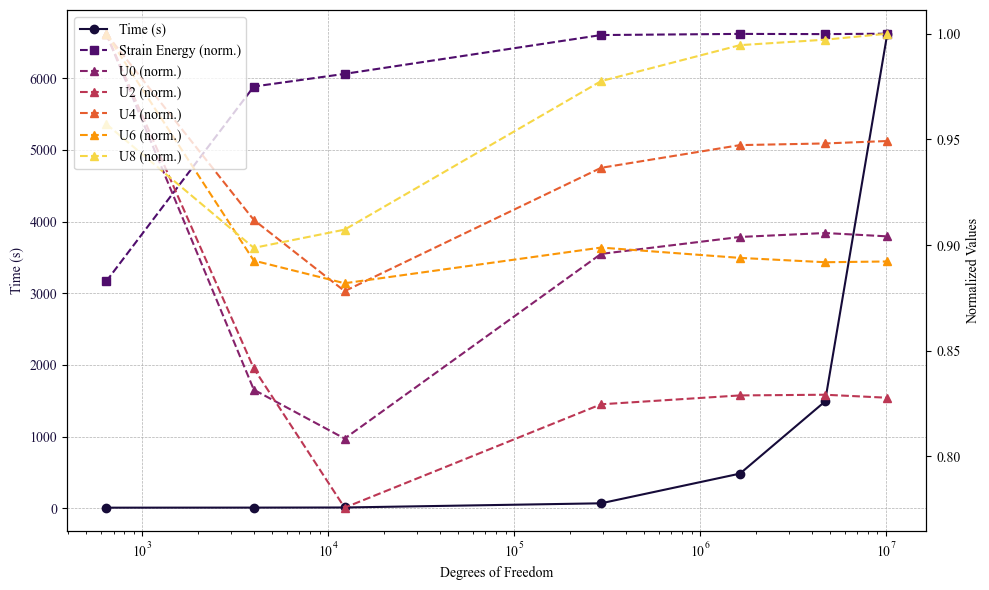

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Schriftart auf Times New Roman setzen
mpl.rcParams["font.family"] = "Times New Roman"

# CSV-Datei einlesen
csv_path = "/Applications/Datein_Timon/Bildung/Uni_Rostock/Master_MaschBau/3_Semester/Studienarbeit/Code/FCM-StA/outputsWuerfel1/convergence.csv"
df = pd.read_csv(csv_path)

# Nach DOFs sortieren
df_sorted = df.sort_values(by="DOFs")

# Daten extrahieren
dofs = df_sorted["DOFs"]
time = df_sorted["TimeSeconds"]
strain_energy = df_sorted["StrainEnergyDot"]
strain_energy_norm = strain_energy / strain_energy.max()

# U1, U2 normalisieren
u_cols = [f"U{i}" for i in range(0, 10,2)]
u_data = df_sorted[u_cols]
u_data_norm = u_data.divide(u_data.max())

# Farben aus inferno-Colormap holen
num_curves = 1 + 1 + len(u_cols)  # Time + Strain + U1,U2,...
cmap = plt.get_cmap("inferno")
colors = cmap(np.linspace(0.1, 0.9, num_curves))  # gleichmäßig verteilt

# Plot erstellen
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Plot 1: Time (linke Y-Achse)
ax1.plot(dofs, time, 'o-', label="Time (s)", color=colors[0], markersize=6)
ax1.set_ylabel("Time (s)", color=colors[0])
ax1.set_xlabel("Degrees of Freedom")
ax1.set_xscale('log')
ax1.tick_params(axis='y', labelcolor=colors[0])
ax1.grid(True, linestyle='--', linewidth=0.5)

# Plot 2+: Strain Energy + U1, U2 (rechte Y-Achse)
ax2.plot(dofs, strain_energy_norm, 's--', label="Strain Energy (norm.)", color=colors[1], markersize=6)

for i, col in enumerate(u_cols):
    ax2.plot(dofs, u_data_norm[col], '--^', label=f"{col} (norm.)", color=colors[i + 2], markersize=6)

ax2.set_ylabel("Normalized Values", color="black")
ax2.tick_params(axis='y', labelcolor="black")

# Legende kombinieren
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Rahmen anzeigen
for spine in ['top', 'right', 'bottom', 'left']:
    ax1.spines[spine].set_visible(True)
    ax2.spines[spine].set_visible(True)

plt.tight_layout()
plt.show()
